# 🧪 10 Solved Concrete Cases: itertools × NumPy × Pandas × Matplotlib

| # | Case | Libraries |
|---|------|-----------|
| 1 | Monthly Sales Analysis | `pandas`, `numpy`, `matplotlib` |
| 2 | All Possible Team Formations | `itertools`, `pandas` |
| 3 | Stock Price Random Walk Simulation | `numpy`, `matplotlib` |
| 4 | Cartesian Product: Product × Region Matrix | `itertools.product`, `pandas` |
| 5 | Permutation-based A/B Test Analysis | `itertools.permutations`, `pandas`, `numpy` |
| 6 | Group-wise Statistics with itertools.groupby | `itertools.groupby`, `pandas`, `numpy` |
| 7 | Best Feature Combinations (Regression) | `itertools.combinations`, `numpy`, `matplotlib` |
| 8 | Merging Multiple Data Sources with chain | `itertools.chain`, `pandas` |
| 9 | Joint Probability Distribution Visualization | `itertools.product`, `numpy`, `matplotlib` |
| 10 | Optimal Meeting Schedule (Permutation Search) | `itertools.permutations`, `pandas`, `numpy` |

---

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline
np.random.seed(42)

---
## 📊 Case 1: Monthly Sales Analysis (pandas + numpy + matplotlib)

**Problem**: Analyze 12 months of sales data. Compute moving averages, growth rates, and visualize trends.

📋 Sales DataFrame:


,Month,Sales,Costs,Profit,Growth_Rate,MA_3
0,2024-01-31,65795,35818.78,29976.22,NaN,NaN
1,2024-02-29,53587,31493.64,22093.36,-18.55,NaN
2,2024-03-31,110340,44153.19,66186.81,105.91,76574.00
3,2024-04-30,64446,38567.21,25878.79,-41.59,76124.33
4,2024-05-31,98103,51356.56,46746.44,52.23,90963.00
5,2024-06-30,107767,56290.01,51476.99,9.85,90105.33
6,2024-07-31,126626,50829.36,75796.64,17.50,110832.00
7,2024-08-31,85113,34437.78,50675.22,-32.78,106502.00
8,2024-09-30,112908,57013.45,55894.55,32.66,108215.67
9,2024-10-31,141766,68043.74,73722.26,25.56,113262.33


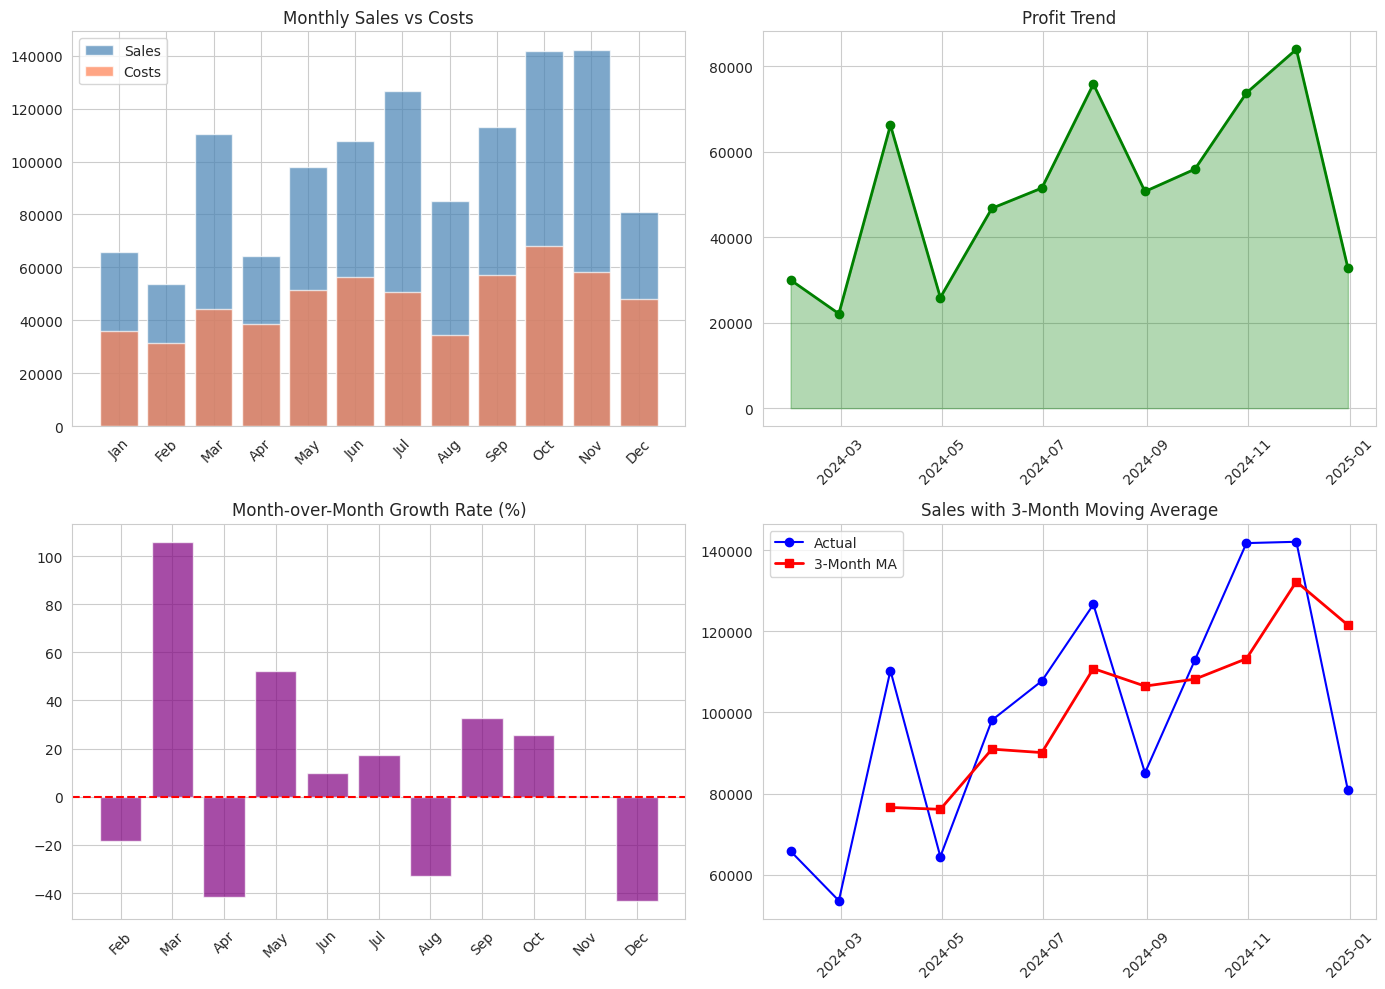


📈 Total Sales: $1,189,312
💰 Total Profit: $615,108
📊 Avg Growth Rate: 9.80%


In [2]:
# Generate 12 months of sales data
months = pd.date_range('2024-01-01', periods=12, freq='M')
sales = np.random.randint(50000, 120000, size=12) + np.linspace(0, 30000, 12).astype(int)

df_sales = pd.DataFrame({
    'Month': months,
    'Sales': sales,
    'Costs': sales * np.random.uniform(0.4, 0.6, 12)
})

df_sales['Profit'] = df_sales['Sales'] - df_sales['Costs']
df_sales['Growth_Rate'] = df_sales['Sales'].pct_change() * 100
df_sales['MA_3'] = df_sales['Sales'].rolling(window=3).mean()

print("📋 Sales DataFrame:")
display(df_sales.round(2))

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sales & Costs
axes[0,0].bar(df_sales['Month'].dt.strftime('%b'), df_sales['Sales'], color='steelblue', alpha=0.7, label='Sales')
axes[0,0].bar(df_sales['Month'].dt.strftime('%b'), df_sales['Costs'], color='coral', alpha=0.7, label='Costs')
axes[0,0].set_title('Monthly Sales vs Costs')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Profit Trend
axes[0,1].plot(df_sales['Month'], df_sales['Profit'], marker='o', color='green', linewidth=2)
axes[0,1].fill_between(df_sales['Month'], df_sales['Profit'], alpha=0.3, color='green')
axes[0,1].set_title('Profit Trend')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Growth Rate
axes[1,0].bar(df_sales['Month'].dt.strftime('%b'), df_sales['Growth_Rate'], color='purple', alpha=0.7)
axes[1,0].axhline(y=0, color='red', linestyle='--')
axes[1,0].set_title('Month-over-Month Growth Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Moving Average
axes[1,1].plot(df_sales['Month'], df_sales['Sales'], marker='o', label='Actual', color='blue')
axes[1,1].plot(df_sales['Month'], df_sales['MA_3'], marker='s', label='3-Month MA', color='red', linewidth=2)
axes[1,1].set_title('Sales with 3-Month Moving Average')
axes[1,1].legend()
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n📈 Total Sales: ${df_sales['Sales'].sum():,.0f}")
print(f"💰 Total Profit: ${df_sales['Profit'].sum():,.0f}")
print(f"📊 Avg Growth Rate: {df_sales['Growth_Rate'].mean():.2f}%")

---
## 👥 Case 2: All Possible Team Formations (itertools + pandas)

**Problem**: From 6 employees, form all possible teams of 3. Analyze team compositions.

🔢 Total possible teams of 3 from 6: 20

📋 Total team-role assignments: 120


,Team,Lead,Member1,Member2,Role_Lead,Role_M1,Role_M2
0,"Alice, Bob, Charlie",Alice,Bob,Charlie,Dev,QA,PM
1,"Alice, Bob, Charlie",Alice,Bob,Charlie,Dev,PM,QA
2,"Alice, Bob, Charlie",Alice,Bob,Charlie,QA,Dev,PM
3,"Alice, Bob, Charlie",Alice,Bob,Charlie,QA,PM,Dev
4,"Alice, Bob, Charlie",Alice,Bob,Charlie,PM,Dev,QA
5,"Alice, Bob, Charlie",Alice,Bob,Charlie,PM,QA,Dev
6,"Alice, Bob, Diana",Alice,Bob,Diana,Dev,QA,PM
7,"Alice, Bob, Diana",Alice,Bob,Diana,Dev,PM,QA
8,"Alice, Bob, Diana",Alice,Bob,Diana,QA,Dev,PM
9,"Alice, Bob, Diana",Alice,Bob,Diana,QA,PM,Dev



👑 Times each person appears as Lead:
Lead
Alice      60
Bob        36
Charlie    18
Diana       6
Name: count, dtype: int64


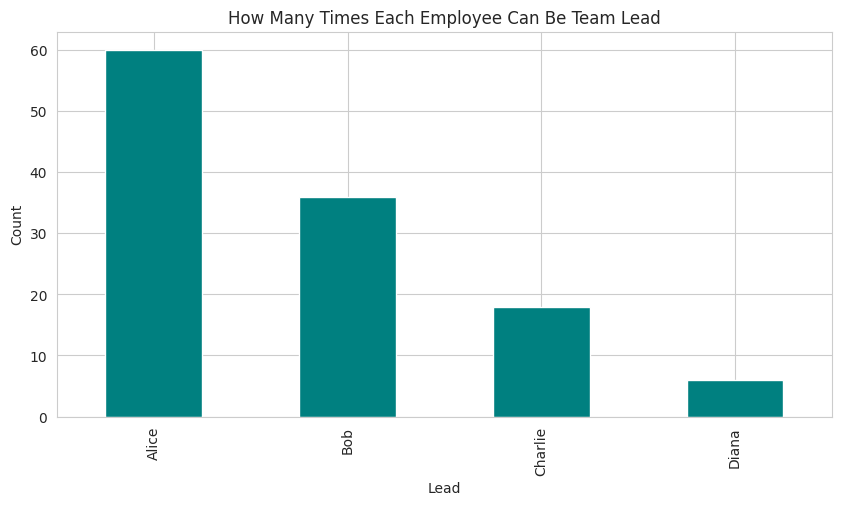

In [3]:
employees = ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank']
roles = ['Dev', 'QA', 'PM']

# All combinations of 3 people
teams = list(itertools.combinations(employees, 3))
print(f"🔢 Total possible teams of 3 from 6: {len(teams)}")

# All permutations (role assignments within each team)
team_assignments = []
for team in teams:
    for role_perm in itertools.permutations(roles):
        team_assignments.append({
            'Team': ', '.join(team),
            'Lead': team[0],
            'Member1': team[1],
            'Member2': team[2],
            'Role_Lead': role_perm[0],
            'Role_M1': role_perm[1],
            'Role_M2': role_perm[2]
        })

df_teams = pd.DataFrame(team_assignments)
print(f"\n📋 Total team-role assignments: {len(df_teams)}")
display(df_teams.head(10))

# Count how many times each person is lead
lead_counts = df_teams['Lead'].value_counts()
print("\n👑 Times each person appears as Lead:")
print(lead_counts)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
lead_counts.plot(kind='bar', color='teal', ax=ax)
ax.set_title('How Many Times Each Employee Can Be Team Lead')
ax.set_ylabel('Count')
plt.show()

---
## 📈 Case 3: Stock Price Random Walk Simulation (numpy + matplotlib)

**Problem**: Simulate 252 trading days of stock prices using Geometric Brownian Motion.

📈 Starting Price: $100.00
📈 Ending Price: $104.92
📊 Total Return: 4.92%


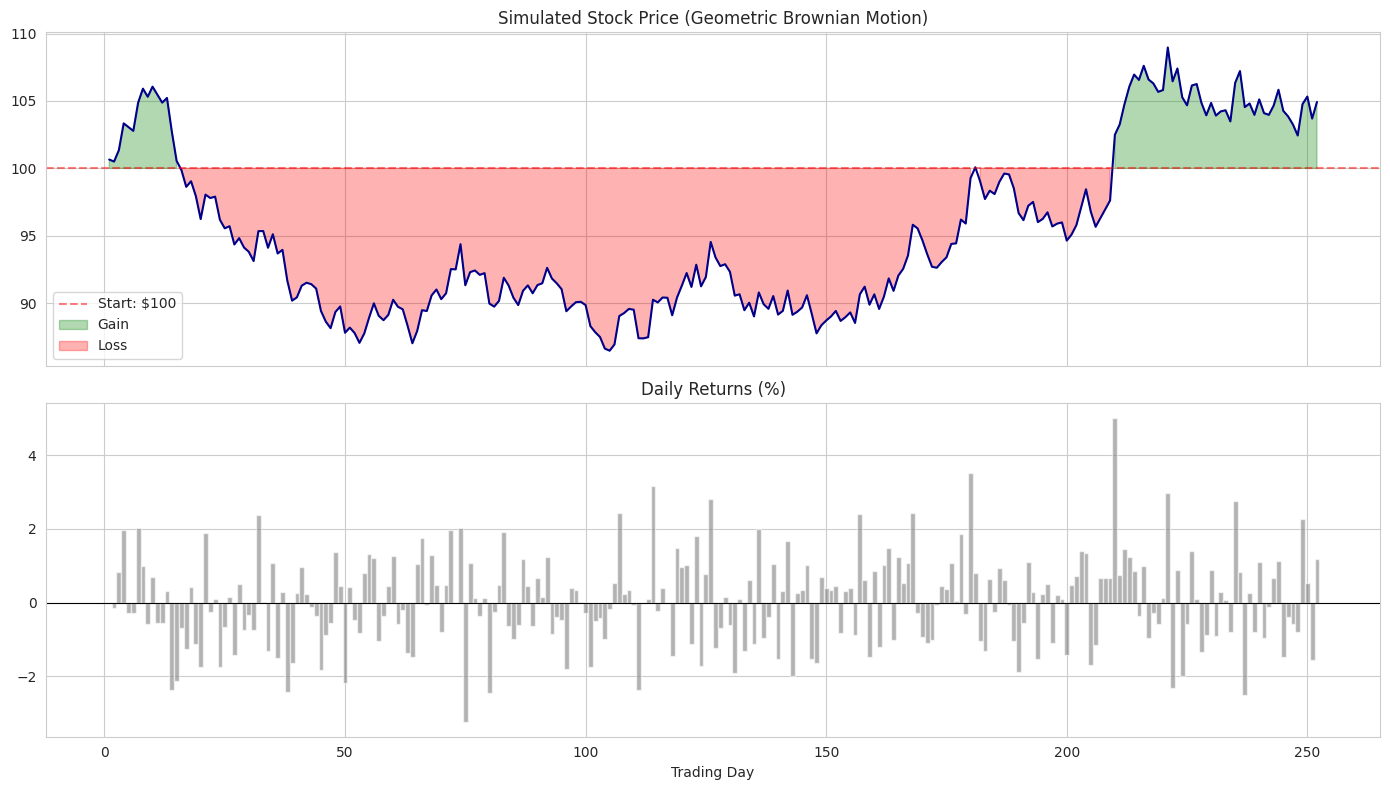


📊 Mean Daily Return: 0.0239%
📊 Std Daily Return: 1.2206%
📊 Max Drawdown: 18.47%


In [4]:
np.random.seed(42)
days = 252
S0 = 100        # Initial price
mu = 0.08       # Annual return
sigma = 0.2     # Volatility
dt = 1/252      # Daily time step

# Generate daily returns
daily_returns = np.random.normal((mu - 0.5*sigma**2)*dt, sigma*np.sqrt(dt), days)
price_path = S0 * np.exp(np.cumsum(daily_returns))

df_stock = pd.DataFrame({
    'Day': range(1, days+1),
    'Price': price_path,
    'Return': np.insert(np.diff(price_path)/price_path[:-1], 0, 0)
})

print(f"📈 Starting Price: ${S0:.2f}")
print(f"📈 Ending Price: ${price_path[-1]:.2f}")
print(f"📊 Total Return: {((price_path[-1]/S0)-1)*100:.2f}%")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_stock['Day'], df_stock['Price'], color='darkblue', linewidth=1.5)
axes[0].axhline(y=S0, color='red', linestyle='--', alpha=0.5, label=f'Start: ${S0}')
axes[0].fill_between(df_stock['Day'], S0, df_stock['Price'], 
                     where=(df_stock['Price']>=S0), alpha=0.3, color='green', label='Gain')
axes[0].fill_between(df_stock['Day'], S0, df_stock['Price'], 
                     where=(df_stock['Price']<S0), alpha=0.3, color='red', label='Loss')
axes[0].set_title('Simulated Stock Price (Geometric Brownian Motion)')
axes[0].legend()

axes[1].bar(df_stock['Day'], df_stock['Return']*100, color='gray', alpha=0.6, width=1)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('Daily Returns (%)')
axes[1].set_xlabel('Trading Day')

plt.tight_layout()
plt.show()

# Statistics
print(f"\n📊 Mean Daily Return: {df_stock['Return'].mean()*100:.4f}%")
print(f"📊 Std Daily Return: {df_stock['Return'].std()*100:.4f}%")
print(f"📊 Max Drawdown: {((df_stock['Price'].cummax() - df_stock['Price'])/df_stock['Price'].cummax()).max()*100:.2f}%")

---
## 🧮 Case 4: Cartesian Product — Product × Region Revenue Matrix (itertools.product + pandas)

**Problem:** Generate all Product×Region combinations and simulate revenue for each.

🔢 Total combinations: 64 (= 4×4×4)

📋 Revenue Pivot Table (Product × Region):


Region,East,North,South,West
Product,,,,
Laptop,552512.0,881233.0,589576.0,325035.0
Phone,624159.0,555500.0,594968.0,544706.0
Tablet,497896.0,522400.0,355883.0,580225.0
Watch,431948.0,631264.0,390621.0,307250.0


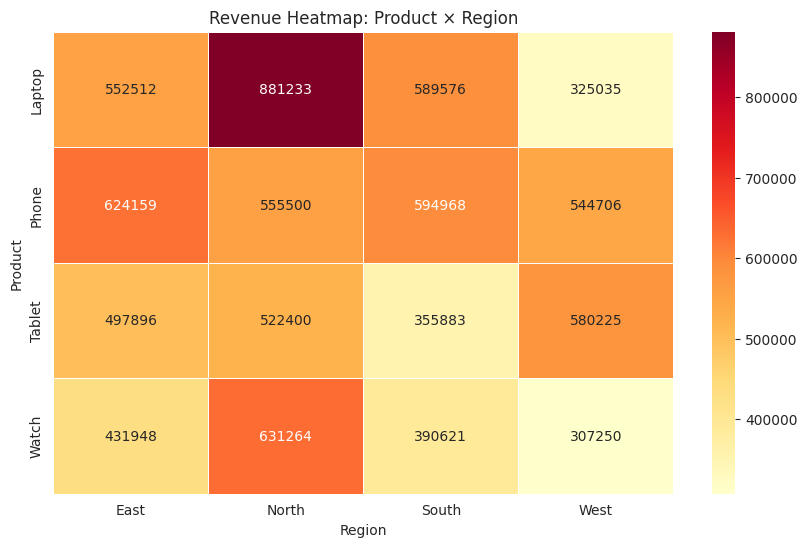


💰 Total Revenue: $8,385,176
🏆 Best Product: Laptop ($2,348,356)


In [5]:
products = ['Laptop', 'Phone', 'Tablet', 'Watch']
regions = ['North', 'South', 'East', 'West']
quarters = ['Q1', 'Q2', 'Q3', 'Q4']

# Full Cartesian product
combinations = list(itertools.product(products, regions, quarters))
print(f"🔢 Total combinations: {len(combinations)} (= {len(products)}×{len(regions)}×{len(quarters)})")

# Simulate revenue
np.random.seed(42)
data = []
for prod, reg, qtr in combinations:
        base = np.random.randint(50000, 200000)
        season_factor = {'Q1':0.8, 'Q2':1.0, 'Q3':1.1, 'Q4':1.3}[qtr]
        region_factor = {'North':1.2, 'South':0.9, 'East':1.0, 'West':0.85}[reg]
        revenue = base * season_factor * region_factor
        data.append({'Product': prod, 'Region': reg, 'Quarter': qtr, 'Revenue': revenue})

df_revenue = pd.DataFrame(data)

# Pivot table
pivot = df_revenue.pivot_table(values='Revenue', index='Product', columns='Region', aggfunc='sum')
print("\n📋 Revenue Pivot Table (Product × Region):")
display(pivot.round(0))

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Revenue Heatmap: Product × Region')
plt.ylabel('Product')
plt.xlabel('Region')
plt.show()

print(f"\n💰 Total Revenue: ${df_revenue['Revenue'].sum():,.0f}")
print(f"🏆 Best Product: {df_revenue.groupby('Product')['Revenue'].sum().idxmax()} (${df_revenue.groupby('Product')['Revenue'].sum().max():,.0f})")

---
## 🧪 Case 5: Permutation-based A/B Test Analysis (itertools.permutations + pandas + numpy)

**Problem:** Given 8 users with conversion outcomes, enumerate ALL possible ways to split into Control (4) and Treatment (4). Compute p-value exactly.

📋 User Data:


,User,Converted
0,U1,1
1,U2,0
2,U3,1
3,U4,1
4,U5,0
5,U6,1
6,U7,0
7,U8,1



🎯 Observed conversions in Treatment: 5 out of 8
🔢 Total possible splits: 70

📊 Exact Two-Tailed P-Value: 1.0000


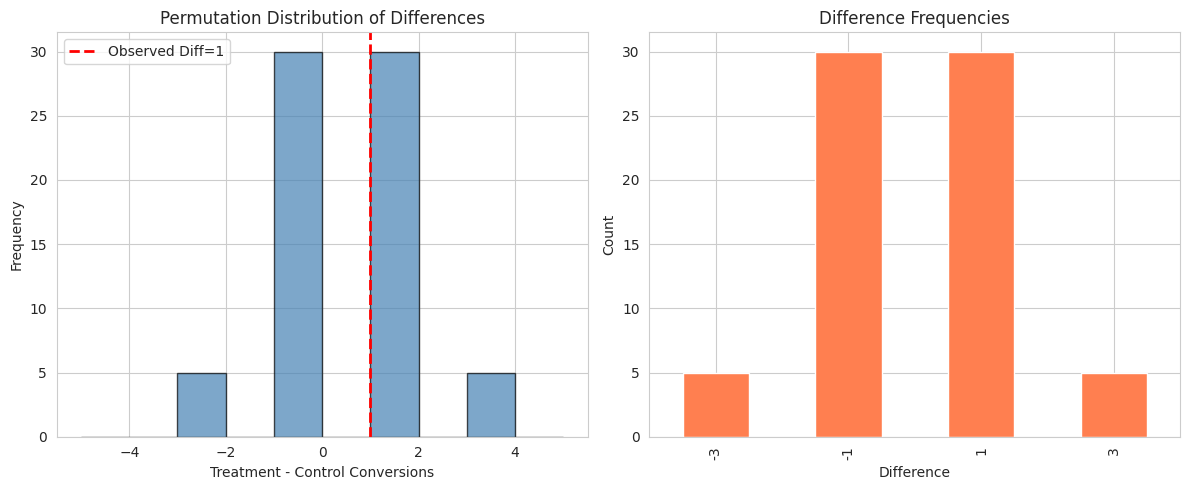

In [6]:
users = ['U1','U2','U3','U4','U5','U6','U7','U8']
converted = [1, 0, 1, 1, 0, 1, 0, 1]  # 1=converted, 0=not

df_users = pd.DataFrame({'User': users, 'Converted': converted})
print("📋 User Data:")
display(df_users)

observed_diff = df_users[df_users['Converted']==1].shape[0] - 4  # observed conversions in treatment
print(f"\n🎯 Observed conversions in Treatment: {df_users['Converted'].sum()} out of 8")

# Enumerate ALL C(8,4) = 70 splits
all_splits = list(itertools.combinations(range(8), 4))
print(f"🔢 Total possible splits: {len(all_splits)}")

results = []
for treatment_idx in all_splits:
    treatment_conv = sum(converted[i] for i in treatment_idx)
    control_conv = sum(converted) - treatment_conv
    diff = treatment_conv - control_conv
    results.append({'Treatment_Conv': treatment_conv, 'Diff': diff})

df_perm = pd.DataFrame(results)

# Exact p-value (two-tailed)
observed = df_users['Converted'].sum()
p_value = (np.abs(df_perm['Diff']) >= np.abs(observed - 4)).mean()

print(f"\n📊 Exact Two-Tailed P-Value: {p_value:.4f}")

# Visualize permutation distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_perm['Diff'], bins=range(-5, 6), color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=observed-4, color='red', linestyle='--', linewidth=2, label=f'Observed Diff={observed-4}')
plt.title('Permutation Distribution of Differences')
plt.xlabel('Treatment - Control Conversions')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
diff_counts = df_perm['Diff'].value_counts().sort_index()
diff_counts.plot(kind='bar', color='coral', ax=plt.gca())
plt.title('Difference Frequencies')
plt.xlabel('Difference')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

---
## 📦 Case 6: Group-wise Statistics with itertools.groupby (itertools + pandas + numpy)

**Problem:** Group transactions by category and compute statistics. Use `itertools.groupby` (note: different from pandas groupby!).

In [ ]:
# Generate transaction data
np.random.seed(42)
categories = ['Food', 'Food', 'Food', 'Transport', 'Transport', 'Entertainment', 'Entertainment', 'Entertainment', 'Entertainment']
amounts = np.random.randint(10, 500, size=100)
data = list(zip(np.random.choice(categories, 100), amounts))

# Sort by category (required for itertools.groupby)
data.sort(key=lambda x: x[0])

# Use itertools.groupby
print("🔧 Using itertools.groupby (requires sorted data):")
grouped = itertools.groupby(data, key=lambda x: x[0])

results = []
for category, group in grouped:
    group_list = list(group)
    amounts_list = [g[1] for g in group_list]
    results.append({
        'Category': category,
        'Count': len(amounts_list),
        'Total': np.sum(amounts_list),
        'Mean': np.mean(amounts_list),
        'Std': np.std(amounts_list),
        'Min': np.min(amounts_list),
        'Max': np.max(amounts_list)
    })

df_stats = pd.DataFrame(results)
print("\n📋 Group Statistics:")
display(df_stats.round(2))

# Compare with pandas groupby
df_trans = pd.DataFrame(data, columns=['Category', 'Amount'])
df_pandas_stats = df_trans.groupby('Category')['Amount'].agg(['count', 'sum', 'mean', 'std', 'min', 'max']).round(2)
print("\n📋 Pandas groupby (for comparison):")
display(df_pandas_stats)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_stats))
width = 0.35
ax.bar(x - width/2, df_stats['Mean'], width, label='Mean', color='steelblue')
ax.bar(x + width/2, df_stats['Total'], width, label='Total', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(df_stats['Category'])
ax.set_title('Category-wise Statistics')
ax.legend()
plt.show()

---
## 🔬 Case 7: Best Feature Combinations for Regression (itertools.combinations + numpy + matplotlib)

**Problem:** From 5 features, find the best 2-feature and 3-feature linear regression models using R².

In [ ]:
np.random.seed(42)
n = 100

# Generate 5 features
X1 = np.random.randn(n)
X2 = np.random.randn(n)
X3 = np.random.randn(n)
X4 = np.random.randn(n)
X5 = np.random.randn(n)

# True model: y = 2*X1 + 3*X2 - 1.5*X3 + noise
y = 2*X1 + 3*X2 - 1.5*X3 + np.random.randn(n)*0.5

features = {'X1': X1, 'X2': X2, 'X3': X3, 'X4': X4, 'X5': X5}
feature_names = list(features.keys())

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - ss_res/ss_tot

# Test all 2-feature and 3-feature combinations
results = []

for k in [2, 3]:
    for combo in itertools.combinations(feature_names, k):
        X = np.column_stack([features[f] for f in combo])
        # Add intercept
        X_with_intercept = np.column_stack([np.ones(n), X])
        beta = np.linalg.lstsq(X_with_intercept, y, rcond=None)[0]
        y_pred = X_with_intercept @ beta
        r2 = r2_score(y, y_pred)
        results.append({'Features': ', '.join(combo), 'K': k, 'R2': r2})

df_models = pd.DataFrame(results).sort_values('R2', ascending=False)

print("🏆 Top 10 Models by R²:")
display(df_models.head(10).round(4))

# Visualize R² for all combos
fig, ax = plt.subplots(figsize=(14, 5))

for k, color in [(2, 'steelblue'), (3, 'coral')]:
    subset = df_models[df_models['K']==k].sort_values('R2', ascending=True)
    ax.barh(range(len(subset)), subset['R2'], color=color, alpha=0.7, label=f'{k} features')
    ax.set_yticks(range(len(subset)))
    ax.set_yticklabels(subset['Features'])

ax.set_xlabel('R² Score')
ax.set_title('R² Score for All Feature Combinations')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n✅ Best 2-feature model: {df_models[df_models['K']==2].iloc[0]['Features']} (R²={df_models[df_models['K']==2].iloc[0]['R2']:.4f})")
print(f"✅ Best 3-feature model: {df_models[df_models['K']==3].iloc[0]['Features']} (R²={df_models[df_models['K']==3].iloc[0]['R2']:.4f})")

---
## 🔗 Case 8: Merging Multiple Data Sources with itertools.chain (itertools + pandas)

**Problem:** Merge 4 separate data sources (as if reading 4 CSVs) into one DataFrame using `itertools.chain`.

In [ ]:
# Simulate 4 data sources (like 4 CSV files)
source1 = pd.DataFrame({'ID': range(1,6), 'Name': [f'Person_{i}' for i in range(1,6)], 'Source': 'File_A'})
source2 = pd.DataFrame({'ID': range(4,9), 'Name': [f'Person_{i}' for i in range(4,9)], 'Source': 'File_B'})
source3 = pd.DataFrame({'ID': range(7,12), 'Name': [f'Person_{i}' for i in range(7,12)], 'Source': 'File_C'})
source4 = pd.DataFrame({'ID': range(10,14), 'Name': [f'Person_{i}' for i in range(10,14)], 'Source': 'File_D'})

print("📄 4 Data Sources:")
for i, src in enumerate([source1, source2, source3, source4], 1):
    print(f"\n  Source {i}:")
    display(src)

# Method 1: pandas concat (standard way)
df_concat = pd.concat([source1, source2, source3, source4], ignore_index=True)

# Method 2: itertools.chain (alternative)
chained_data = list(itertools.chain(
    source1.to_dict('records'),
    source2.to_dict('records'),
    source3.to_dict('records'),
    source4.to_dict('records')
))
df_chain = pd.DataFrame(chained_data)

print("\n✅ Merged DataFrame (via itertools.chain):")
display(df_chain)

print(f"📊 Total records: {len(df_chain)}")
print(f"🔄 Duplicates (by ID): {df_chain.duplicated(subset=['ID']).sum()}")

# Also demonstrate islice — take first 5 records
print("\n🔪 First 5 records via itertools.islice:")
first_5 = list(itertools.islice(itertools.chain(
    source1.to_dict('records'),
    source2.to_dict('records'),
    source3.to_dict('records'),
    source4.to_dict('records')
), 5))
display(pd.DataFrame(first_5))

# Visualize source distribution
plt.figure(figsize=(8, 5))
df_chain['Source'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Record Distribution by Source')
plt.ylabel('')
plt.show()

---
## 🎲 Case 9: Joint Probability Distribution Visualization (itertools.product + numpy + matplotlib)

**Problem:** Two dice — compute and visualize the joint probability distribution of all 36 outcomes.

In [ ]:
# Two dice
dice1 = [1, 2, 3, 4, 5, 6]
dice2 = [1, 2, 3, 4, 5, 6]

# All outcomes via product
outcomes = list(itertools.product(dice1, dice2))
sums = [d1 + d2 for d1, d2 in outcomes]

# Compute probabilities
unique_sums, counts = np.unique(sums, return_counts=True)
probs = counts / len(outcomes)

df_dice = pd.DataFrame({
    'Die1': [o[0] for o in outcomes],
    'Die2': [o[1] for o in outcomes],
    'Sum': sums
})

# Pivot for heatmap
pivot_dice = df_dice.pivot_table(index='Die1', columns='Die2', values='Sum', aggfunc='first')
count_pivot = df_dice.pivot_table(index='Die1', columns='Die2', values='Sum', aggfunc='count')

print("🎲 All 36 Outcomes (first 10):")
display(df_dice.head(10))

print("\n📊 Sum Distribution:")
df_sum_dist = pd.DataFrame({'Sum': unique_sums, 'Count': counts, 'Probability': probs})
display(df_sum_dist.round(4))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Heatmap of sums
sns.heatmap(pivot_dice, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Sum'})
axes[0].set_title('Sum of Two Dice (Heatmap)')

# 2. Probability distribution
axes[1].bar(unique_sums, probs, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_xticks(unique_sums)
axes[1].set_xlabel('Sum')
axes[1].set_ylabel('Probability')
axes[1].set_title('Probability Distribution of Sums')

# 3. 3D-like surface plot
from mpl_toolkits.mplot3d import Axes3D
ax3d = fig.add_subplot(1, 3, 3, projection='3d')
x, y = np.meshgrid(dice1, dice2)
z = x + y
surf = ax3d.plot_surface(x, y, z, cmap='viridis', alpha=0.8, edgecolor='none')
ax3d.set_xlabel('Die 1')
ax3d.set_ylabel('Die 2')
ax3d.set_zlabel('Sum')
ax3d.set_title('3D Surface: Sum = Die1 + Die2')
fig.colorbar(surf, ax=ax3d, shrink=0.5)

plt.tight_layout()
plt.show()

print(f"\n🎯 Most likely sum: {unique_sums[np.argmax(probs)]} (P={probs.max():.4f})")
print(f"🎯 Least likely sums: {unique_sums[probs==probs.min()].tolist()} (P={probs.min():.4f})")

---
## 📅 Case 10: Optimal Meeting Schedule — Permutation Search (itertools.permutations + pandas + numpy)

**Problem:** 5 meetings with different durations. Find the ordering that minimizes total waiting time for all attendees.

🔢 Evaluating all 120 permutations...

🏆 Top 5 Optimal Schedules (lowest waiting time):
  11. Standup → Review → Retro → Planning → 1-on-1 → Wait: 1,335 person-min
  12. Standup → Review → Retro → 1-on-1 → Planning → Wait: 1,345 person-min
  10. Standup → Review → 1-on-1 → Retro → Planning → Wait: 1,385 person-min
  8. Standup → Review → Planning → Retro → 1-on-1 → Wait: 1,395 person-min
  53. Review → Standup → Retro → Planning → 1-on-1 → Wait: 1,425 person-min

📊 Worst 5 Schedules (highest waiting time):
  83. 1-on-1 → Planning → Retro → Standup → Review → Wait: 3,020 person-min
  94. 1-on-1 → Retro → Planning → Review → Standup → Wait: 3,050 person-min
  48. Planning → Retro → 1-on-1 → Review → Standup → Wait: 3,060 person-min
  42. Planning → 1-on-1 → Retro → Review → Standup → Wait: 3,100 person-min
  84. 1-on-1 → Planning → Retro → Review → Standup → Wait: 3,110 person-min


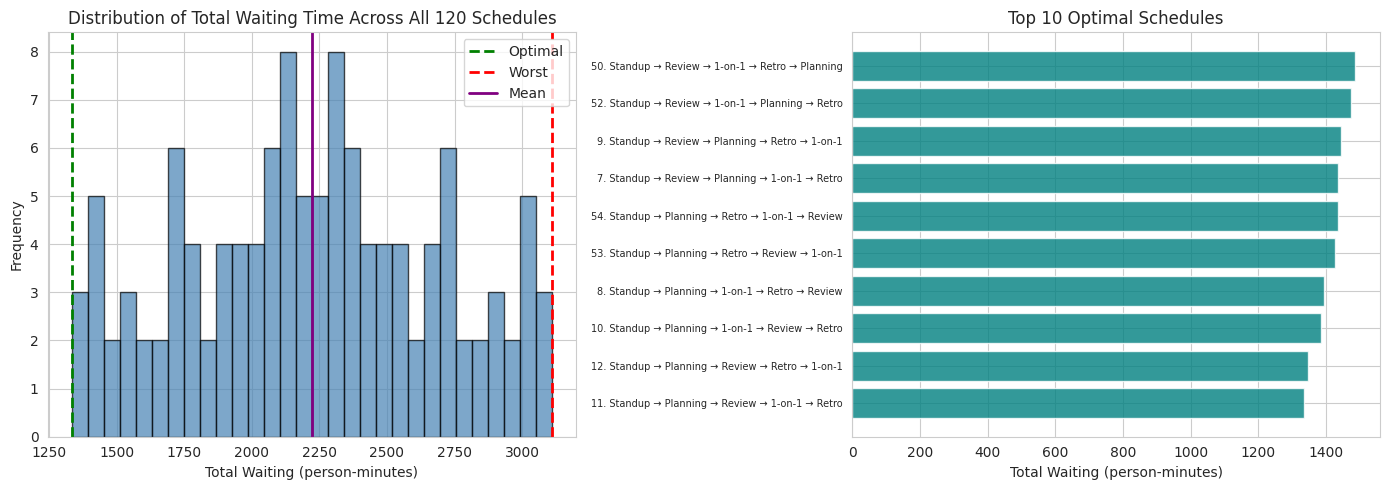


📈 Improvement: 57.1% reduction in waiting time!


In [7]:
meetings = [
    {'name': 'Standup', 'duration': 15, 'attendees': 8},
    {'name': 'Planning', 'duration': 45, 'attendees': 5},
    {'name': 'Review', 'duration': 30, 'attendees': 10},
    {'name': '1-on-1', 'duration': 20, 'attendees': 2},
    {'name': 'Retro', 'duration': 60, 'attendees': 8},
]

meeting_names = [m['name'] for m in meetings]
durations = [m['duration'] for m in meetings]
attendees = [m['attendees'] for m in meetings]

def total_waiting_cost(order_indices):
    """Calculate total person-minutes of waiting."""
    total_wait = 0
    elapsed = 0
    for idx in order_indices:
        total_wait += elapsed * attendees[idx]
        elapsed += durations[idx]
    return total_wait

# Evaluate all 5! = 120 permutations
all_perms = list(itertools.permutations(range(5)))
print(f"🔢 Evaluating all {len(all_perms)} permutations...")

results = []
for perm in all_perms:
    cost = total_waiting_cost(perm)
    results.append({
        'Order': ' → '.join([meeting_names[i] for i in perm]),
        'Total_Wait_Minutes': cost,
        'Total_Duration': sum(durations)
    })

df_schedules = pd.DataFrame(results).sort_values('Total_Wait_Minutes')

print("\n🏆 Top 5 Optimal Schedules (lowest waiting time):")
for i, row in df_schedules.head(5).iterrows():
    print(f"  {i+1}. {row['Order']} → Wait: {row['Total_Wait_Minutes']:,} person-min")

print("\n📊 Worst 5 Schedules (highest waiting time):")
for i, row in df_schedules.tail(5).iterrows():
    print(f"  {i+1}. {row['Order']} → Wait: {row['Total_Wait_Minutes']:,} person-min")

# Visualize distribution of waiting costs
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df_schedules['Total_Wait_Minutes'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=df_schedules['Total_Wait_Minutes'].min(), color='green', linestyle='--', linewidth=2, label='Optimal')
plt.axvline(x=df_schedules['Total_Wait_Minutes'].max(), color='red', linestyle='--', linewidth=2, label='Worst')
plt.axvline(x=df_schedules['Total_Wait_Minutes'].mean(), color='purple', linestyle='-', linewidth=2, label='Mean')
plt.title('Distribution of Total Waiting Time Across All 120 Schedules')
plt.xlabel('Total Waiting (person-minutes)')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
# Show top 10 as horizontal bars
top10 = df_schedules.head(10).sort_values('Total_Wait_Minutes', ascending=True)
y_labels = [f"{i+1}. {' → '.join([meeting_names[j] for j in all_perms[idx]])}" 
            for idx, (i, _) in enumerate(top10.iterrows())]
plt.barh(range(len(top10)), top10['Total_Wait_Minutes'], color='teal', alpha=0.8)
plt.yticks(range(len(top10)), y_labels, fontsize=7)
plt.xlabel('Total Waiting (person-minutes)')
plt.title('Top 10 Optimal Schedules')
plt.tight_layout()

plt.show()

print(f"\n📈 Improvement: {((df_schedules['Total_Wait_Minutes'].max() - df_schedules['Total_Wait_Minutes'].min()) / df_schedules['Total_Wait_Minutes'].max() * 100):.1f}% reduction in waiting time!")